In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import (
    DecisionTreeClassifier,
    plot_tree
)

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [ ]:
from google.colab import files

uploaded = files.upload()

df = pd.read_csv("iris.csv")

df.head()

Saving iris.csv to iris (1).csv


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:
print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nClass Distribution:")
print(df['species'].value_counts())

df.head()

Dataset Shape: (150, 5)

Columns:
Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')

Class Distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:
X = df.drop("species", axis=1)

y = df["species"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (150, 4)
Target Shape: (150,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 120
Testing Samples: 30


In [ ]:
tree_model = DecisionTreeClassifier(
    criterion='gini',
    random_state=42
)

tree_model.fit(X_train, y_train)

print("Decision Tree Trained Successfully")

Decision Tree Trained Successfully


In [ ]:
y_pred = tree_model.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9333333333333333


In [ ]:
f1 = f1_score(
    y_test,
    y_pred,
    average='weighted'
)

print("F1 Score:", f1)

F1 Score: 0.9333333333333333


In [ ]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



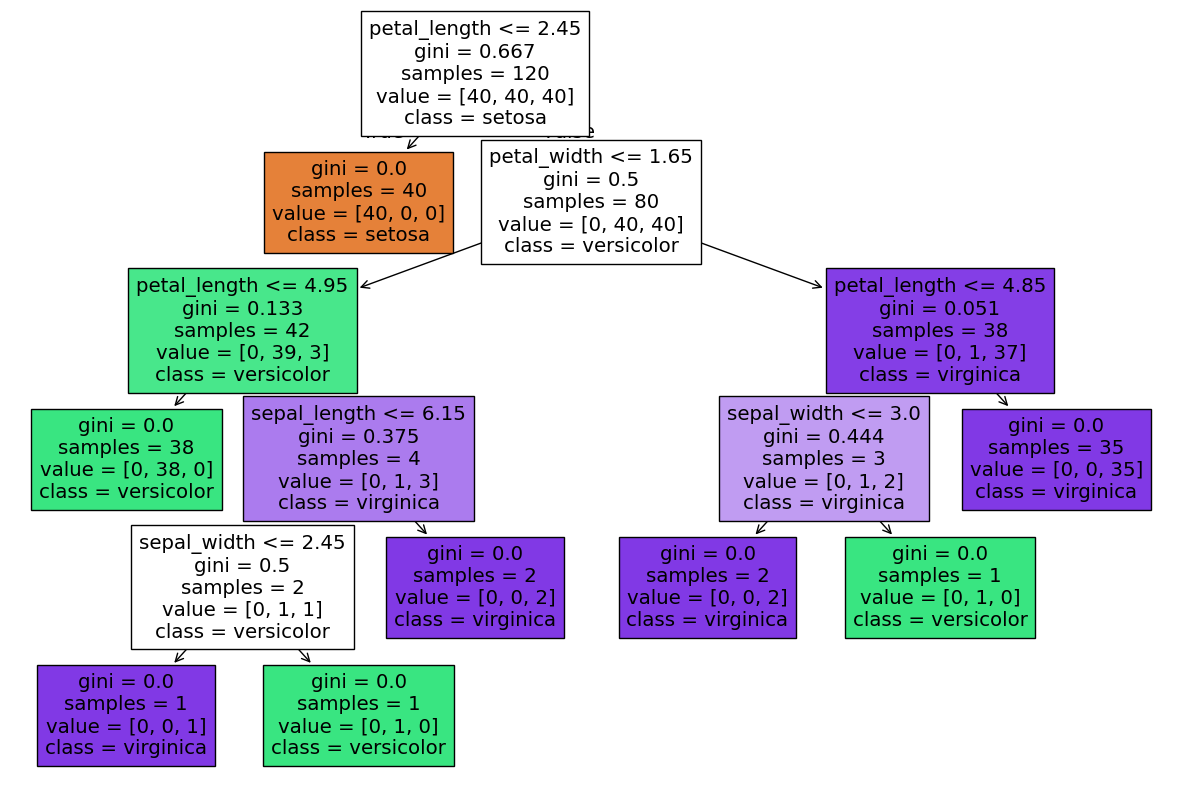

In [ ]:
plt.figure(figsize=(15,10))

plot_tree(
    tree_model,
    feature_names=X.columns,
    class_names=tree_model.classes_,
    filled=True
)

plt.show()

In [ ]:
print("Tree Depth:", tree_model.get_depth())

print("Number of Leaves:", tree_model.get_n_leaves())

Tree Depth: 5
Number of Leaves: 8


In [ ]:
pruned_tree = DecisionTreeClassifier(
    criterion='gini',
    max_depth=3,
    random_state=42
)

pruned_tree.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

In [ ]:
pruned_pred = pruned_tree.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test, pruned_pred))

print("F1 Score:",
      f1_score(
          y_test,
          pruned_pred,
          average='weighted'
      ))

Accuracy: 0.9666666666666667
F1 Score: 0.9665831244778613


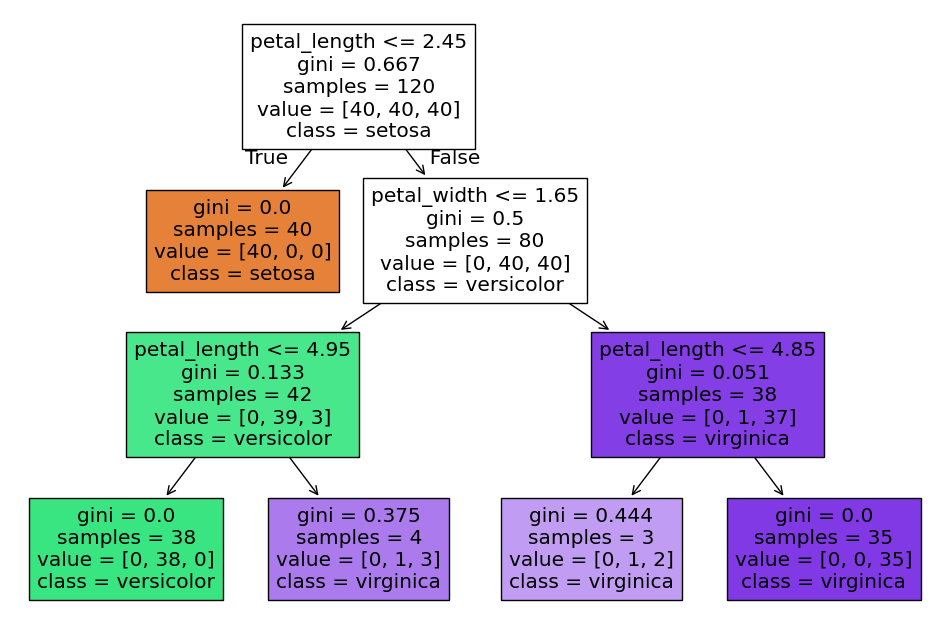

In [ ]:
plt.figure(figsize=(12,8))

plot_tree(
    pruned_tree,
    feature_names=X.columns,
    class_names=pruned_tree.classes_,
    filled=True
)

plt.show()

In [ ]:
original_acc = accuracy_score(y_test, y_pred)

pruned_acc = accuracy_score(
    y_test,
    pruned_pred
)

comparison = pd.DataFrame({
    'Model': ['Original Tree', 'Pruned Tree'],
    'Accuracy': [original_acc, pruned_acc]
})

print(comparison)

           Model  Accuracy
0  Original Tree  0.933333
1    Pruned Tree  0.966667


In [ ]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': tree_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

        Feature  Importance
2  petal_length    0.558568
3   petal_width    0.406015
1   sepal_width    0.029167
0  sepal_length    0.006250


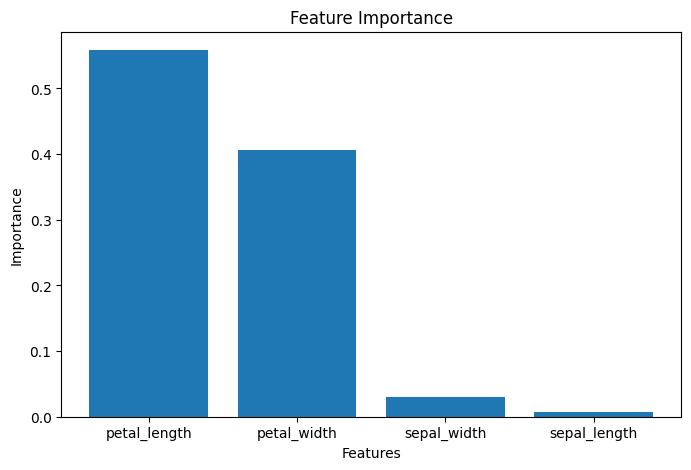

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(
    importance['Feature'],
    importance['Importance']
)

plt.title("Feature Importance")

plt.xlabel("Features")
plt.ylabel("Importance")

plt.show()